# HVAC Electircity Demand Analysis and Prediction

## Feature Creation

### Import Libraries



In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor,RandomForestRegressor

np.random.seed(42)

In [33]:
df_daily = pd.read_csv("./data/df_daily.csv", index_col=0)
df = pd.read_csv("./data/Load_data_01.csv")
df["Time"] = pd.to_datetime(df["Time"])
df.set_index("Time", inplace=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
air_pressure,70080.0,734.587334,5.006131,716.500000,731.400000,734.200000,737.500000,757.500000
air_temperature,70080.0,17.874431,10.669905,-14.400000,10.000000,18.900000,25.600000,43.300000
relative_humidity,70080.0,60.645077,21.979472,4.000000,43.000000,61.000000,79.000000,100.000000
wind_speed,70080.0,4.830608,2.581267,0.000000,3.000000,5.000000,6.000000,26.000000
solar_irridiation,70080.0,257.293094,258.725788,0.000000,0.000000,299.500000,499.000000,699.000000
total_cloud_cover_percent,70080.0,0.323900,0.387351,0.000000,0.000000,0.000000,0.750000,1.000000
electricity_demand_values,70080.0,393.894392,239.177728,112.947618,227.708651,323.095501,476.911512,1592.893206
heat_demand_values,70080.0,263.551003,314.720551,0.000000,0.000000,137.430266,448.333458,1529.168786


In [34]:
df_daily.describe().T


,count,mean,std,min,25%,50%,75%,max
air_pressure,2920.0,734.587334,3.206897,724.691667,732.450000,734.291667,736.489583,747.420833
air_temperature,2920.0,17.874431,9.032153,-5.070833,10.458333,18.229167,26.155208,36.325000
relative_humidity,2920.0,60.645077,11.590058,27.416667,52.708333,61.104167,68.875000,92.750000
wind_speed,2920.0,4.830608,1.029711,1.958333,4.083333,4.791667,5.500000,9.333333
solar_irridiation,2920.0,257.293094,16.957373,201.291667,245.354167,257.416667,268.833333,315.541667
total_cloud_cover_percent,2920.0,0.323900,0.178468,0.000000,0.191120,0.302083,0.427083,0.979167
electricity_demand_values,2920.0,9453.465406,3230.948896,5106.015997,6836.863624,8863.772704,11172.705523,25405.855701


## Create daily dataframe and feature creation

In [35]:
# Collect allavailable solar irradiation data in a day
df["solar_irridiation_positive"] = df["solar_irridiation"][df["solar_irridiation"] > 0]

In [36]:
df["solar_irridiation_positive"].resample("D").count().value_counts() # 13 hours solar irradiation per day

solar_irridiation_positive
13    2920
Name: count, dtype: int64

In [37]:
df["solar_irridiation"][df["solar_irridiation"] == 0].resample("D").count().value_counts()  # 11 hours no solar irradiation per day

solar_irridiation
11    2920
Name: count, dtype: int64

In [38]:
df_daily = pd.DataFrame() # create a new dataframe for daily data

df_daily["electricity_demand_values"] = ( # sum up all electricity demand values in a day
    df["electricity_demand_values"].resample("D").sum() 
)

In [39]:
# Define the columns for mean calculation
mean_cols = [
    "air_pressure",
    "air_temperature",
    "relative_humidity",
    "wind_speed",
    "solar_irridiation_positive",
    "total_cloud_cover_percent",
]

# Calculate the mean for each of the specified columns on a daily basis
for col in mean_cols:
    df_daily[col] = df[col].resample("D").mean()

In [40]:
daily_resampled_wind = df["wind_speed"].resample("D")
df_daily["wind_speed_range"] = (
    daily_resampled_wind.max() - daily_resampled_wind.min()
)  # calculate range of wind speed

In [41]:
def label_wind(wind): # label wind scale
    if wind < 5:
        return "Wind scale 2"
    else:
        return "Wind scale 3"

In [42]:
df_daily["wind_label"] = df_daily["wind_speed"].apply(label_wind) # apply label_wind function to wind speed column
df_wind = pd.get_dummies(df_daily["wind_label"])

for _ in df_wind.columns:   # add wind scale columns to df_daily
    df_daily[_] = df_wind[_].astype(int)

In [43]:
def label_humidity(humidity):   # label humidity
    if humidity < 30:
        return "Uncomfortable Dry"  # 0
    elif humidity > 60:
        return "Uncomfortable Wet"  # 2
    else:
        return "Comfort"  # 1

In [44]:
df_daily["relative_humidity_label"] = df_daily["relative_humidity"].apply(
    label_humidity
)
df_humidity = pd.get_dummies(df_daily["relative_humidity_label"], prefix="huimidity")
for _ in df_humidity.columns:
    df_daily[_] = df_humidity[_].astype(int)


In [45]:
def label_temperature(temp):  # label temperature
    if temp < -10:
        return "temp_less_minus_10"  
    elif temp < 0:
        return "temp_minus_10_0"
    elif temp < 10:
        return "temp_0_10"
    elif temp < 20:
        return "temp_10_20"
    elif temp < 30:
        return "temp_20_30"
    elif temp < 40:
        return "temp_30_40"
    else:
        return "temp_greater_40"


df_daily["temp_range"] = df_daily["air_temperature"].apply(
    label_temperature
)  # apply label_temperature function to air_temperature column
df_temperature = pd.get_dummies(df_daily["temp_range"])

for _ in df_temperature.columns:
    df_daily[_] = df_temperature[_].astype(int)


In [46]:
df_daily.drop( # drop orginal features to avoid multicollinearity
    [
        "air_temperature",
        "wind_speed",
        "relative_humidity",
        "temp_range",
        "relative_humidity_label",
        "wind_label","wind_label"
    ],
    axis=1,
    inplace=True,
)

In [47]:
# create new features from time index
df_daily["Day_of_Week"] = df_daily.index.day_of_week
df_daily["month"] = df_daily.index.month
df_daily = pd.get_dummies(
    df_daily,
    columns=["Day_of_Week", "month"],
    prefix=["Is_Weekday","month"],
)

In [48]:
# Convert dummy variables to integer type

for _ in [
    "Is_Weekday_0",
    "Is_Weekday_1",
    "Is_Weekday_2",
    "Is_Weekday_3",
    "Is_Weekday_4",
    "Is_Weekday_5",
    "Is_Weekday_6",
    "month_1",
    "month_2",
    "month_3",
    "month_4",
    "month_5",
    "month_6",
    "month_7",
    "month_8",
    "month_9",
    "month_10",
    "month_11",
    "month_12",
]:
    df_daily[_] = df_daily[_].astype(int)

In [49]:
# df_daily.to_csv(
#     "./data/df_daily_feature_creation.csv"
# )  # Save the daily DataFrame with created features

## Training and Testing models

In [50]:
# Define a function to split the dataset into training and testing sets
def train_test_set(df, start, end, split_time):
    train = df[(df.index > start) & (df.index <= split_time)]
    test = df[(df.index > split_time) & (df.index <= end)]
    X_train, y_train = (
        train.drop(["electricity_demand_values"], axis=1),
        train["electricity_demand_values"],
    )
    X_test, y_test = (
        test.drop(["electricity_demand_values"], axis=1),
        test["electricity_demand_values"],
    )
    return X_train, y_train, X_test, y_test

In [51]:
def MAPE(y_true, y_pred):  # Calculate Mean Absolute Percentage Error
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_index = y_true != 0
    y_true = y_true[non_zero_index]
    y_pred = y_pred[non_zero_index]
    if len(y_true) == 0:
        return np.nan
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # in percentage

In [96]:
def evaluate_model_performance(y_true, y_pred):  # Evaluate model performance
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = np.mean(np.abs(y_test - y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)
    return round(rmse,4), round(mae,4), round(mape,2), round(r2,4)

In [97]:
def train_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse, mae, mape, r2 = evaluate_model_performance(y_test, y_pred)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.2f} %")
    print(f"R2: {r2:.4f}")
    df_performance = pd.DataFrame(
        {"RMSE": rmse, "MAE": mae, "MAPE(%)": mape, "R2": r2}, index=[0]
    )
    df_results = pd.DataFrame(
        {"Time": y_test.index, "y_test": y_test, "y_pred": y_pred}
    )
    return df_performance,df_results

In [98]:
X_train, y_train, X_test, y_test = train_test_set(
    df_daily, "2017-01-01", "2018-11-20", "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((516, 33), (516,), (172, 33), (172,))

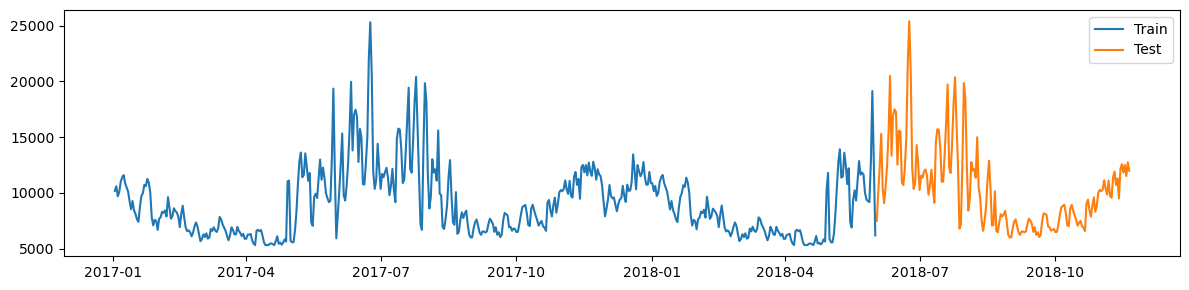

In [99]:
# Plot the train and test data
_, ax = plt.subplots(figsize=(12, 3))

ax.plot(y_train.index, y_train, label="Train")
ax.plot(y_test.index, y_test, label="Test")

plt.legend()
plt.tight_layout()

plt.show()


In [100]:
# Define a function to plot the results
def plot_results(df_results, model_name):
    _, ax = plt.subplots(figsize=(12, 3))
    ax.plot(df_results["Time"], df_results["y_test"], label="Test")
    ax.plot(df_results["Time"], df_results["y_pred"], label="Predicted")
    ax.set_title(model_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [101]:
# Train and evaluate Decision Tree Regressor
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
df_performance, df_results = train_model(X_train, y_train, X_test, y_test, dt_reg)

RMSE: 3675.4119
MAE: 2479.7466
MAPE: 23.80 %
R2: 0.0039


In [102]:
df_performance

,RMSE,MAE,MAPE(%),R2
0,3675.4119,2479.7466,23.8,0.0039


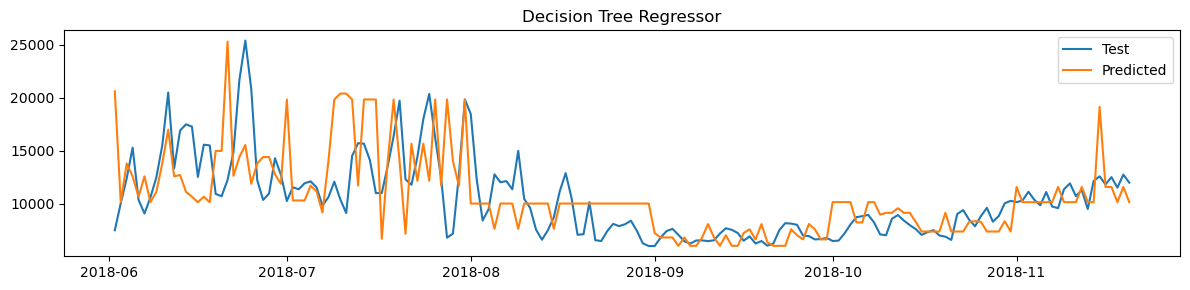

In [103]:
plot_results(df_results, "Decision Tree Regressor")  # Plot the results

In [104]:
# Train and evaluate Random Forest Regressor
RF_reg = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

df_performance, df_results = train_model(X_train, y_train, X_test, y_test, RF_reg)

RMSE: 2913.0264
MAE: 2000.0461
MAPE: 19.11 %
R2: 0.3743


In [105]:
df_performance

,RMSE,MAE,MAPE(%),R2
0,2913.0264,2000.0461,19.11,0.3743


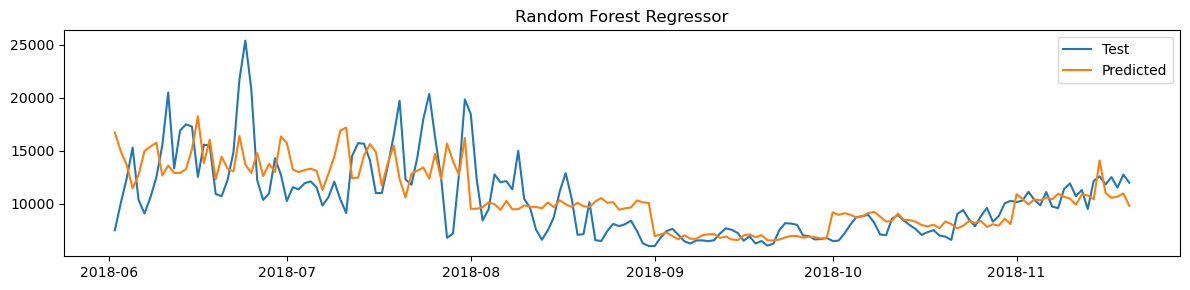

In [106]:
plot_results(df_results, "Random Forest Regressor")  # Plot the results

In [107]:
# Train and evaluate AdaBoost Regressor
ada_reg = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=100,
    random_state=42,
)

df_performance, df_results = train_model(X_train, y_train, X_test, y_test, ada_reg)

RMSE: 3051.6157
MAE: 2054.8736
MAPE: 19.03 %
R2: 0.3133


In [108]:
df_performance

,RMSE,MAE,MAPE(%),R2
0,3051.6157,2054.8736,19.03,0.3133


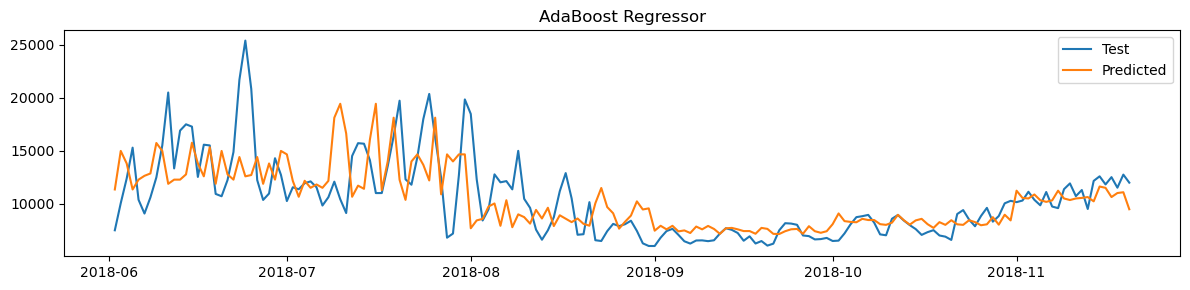

In [109]:
plot_results(df_results, "AdaBoost Regressor")  # Plot the results

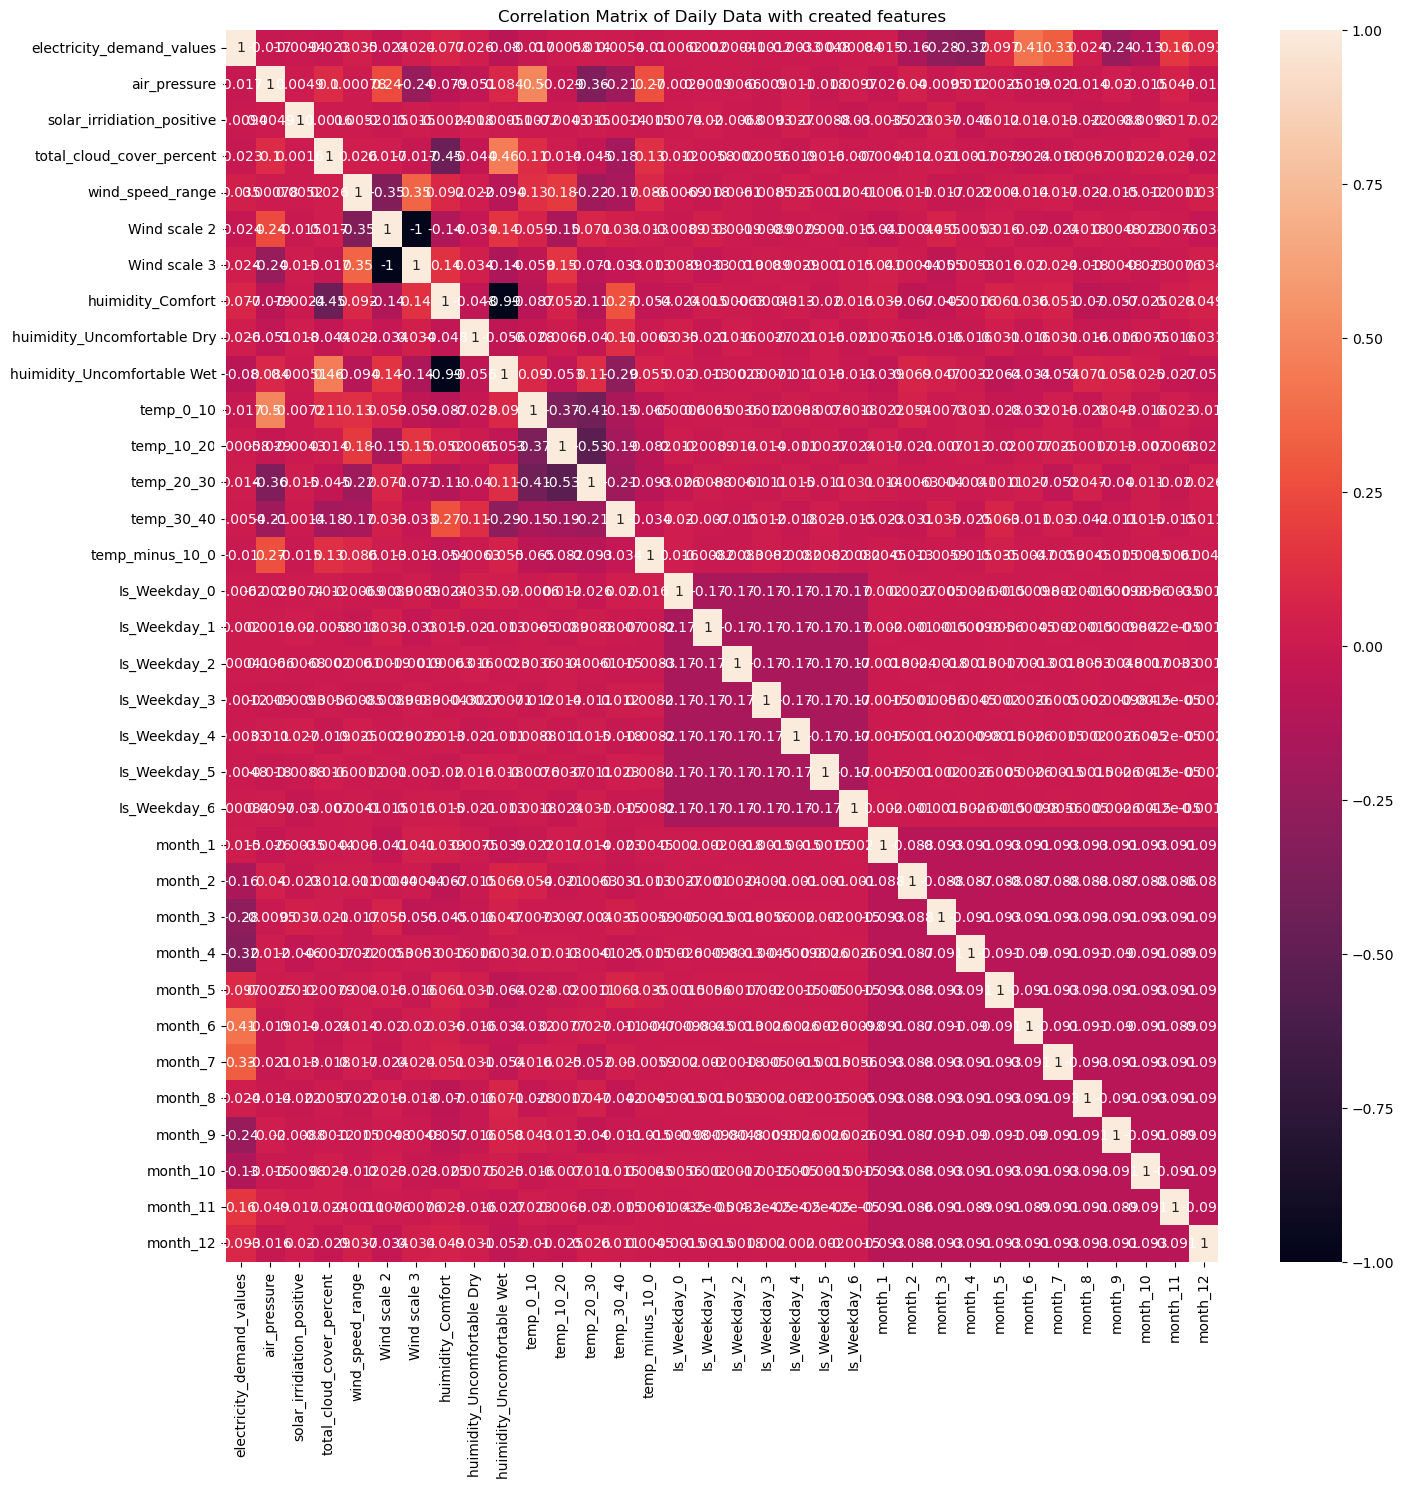

In [110]:
# Plot the correlation matrix of daily data with created features
_, ax = plt.subplots(figsize=(16, 16))
sns.heatmap(df_daily.corr(), annot=True, ax=ax)
ax.set_title("Correlation Matrix of Daily Data with created features")
plt.show()

## Conclusion

- By adding more virtual features, all the models performance are improved.
- While the RMSE,MAE and R-squared are still comparably low.